In [23]:
#!pip install mcpl

import mcpl
import torch
import numpy as np
import matplotlib.pyplot as plt
import zuko
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"device={DEVICE} | torch={torch.__version__} | zuko={zuko.__version__}")

plt.style.use("ggplot")

device=mps | torch=2.5.1 | zuko=1.4.1


In [2]:
!mcpltool filtered_surface_source_5003_2cm_4deg.mcpl.gz

Opened MCPL file filtered_surface_source_5003_2cm_4deg.mcpl.gz:

  Basic info
    Format             : MCPL-3
    No. of particles   : 658561
    Header storage     : 72 bytes
    Data storage       : 23708196 bytes

  Custom meta data
    Source             : "KDSource MCPL writer"
    Number of comments : 0
    Number of blobs    : 0

  Particle data format
    User flags         : no
    Polarisation info  : no
    Fixed part. type   : no
    Fixed part. weight : no
    FP precision       : single
    Endianness         : little
    Storage            : 36 bytes/particle

index     pdgcode   ekin[MeV]       x[cm]       y[cm]       z[cm]          ux          uy          uz    time[ms]      weight
    0        2112     0.02752     -15.166    -0.49307      286.92  -0.0015546     0.99997  -0.0071853      194.13           1
    1        2112    0.019406     -14.859    0.074898      286.92    0.022009     0.99973   0.0075036      310.22           1
    2        2112    0.058947     -15.51

We are interested in modeling the neutron phase-space variables multivariate distribution by means of a Normalizing Flow model! The variables of interest are: $(x,y)$ position of crossing point on the surface, $(ux, uy, uz)$ components of the direction vector, and most importantly $E$ (or some function of $E$) the energy of the neutron.  This results in a 6 dimensional distribution.

In [4]:
class NeutronDataset(torch.utils.data.Dataset):
    def __init__(self, path_mcpl, nparticles=None, standardize=True):
        self.path_mcpl = path_mcpl
        self.dataset = mcpl.MCPLFile(self.path_mcpl)
        self.raw = torch.tensor([(np.log10(p.ekin*1e6), p.x, p.y, p.ux, p.uy, p.uz) for p in self.dataset.particles], dtype=torch.float32)
        # self.raw = torch.tensor([(np.log10(p.ekin*1e6), p.x) for p in self.dataset.particles], dtype=torch.float32)
        if nparticles is not None:
            self.raw = self.raw[:nparticles, :]
            
        self.mean = self.raw.mean(0, keepdim=True)
        self.std = self.raw.std(0, keepdim=True).clamp_min(1e-6)

        self.particles = (self.raw - self.mean) / self.std
        
    def __len__(self):
        return len(self.particles)
    
    def __getitem__(self, idx):
        '''return E[eV], x[cm], y[cm], ux, uy, uz'''
        return self.particles[idx]
                

In [7]:
data = NeutronDataset("filtered_surface_source_5003_2cm_4deg.mcpl.gz", nparticles=4000)
len(data)

4000

In [8]:
data[len(data)-1]

tensor([-0.3396,  0.6894,  0.9234, -0.9551, -0.5779,  1.4576])

Text(0.5, 0, 'log10(E)')

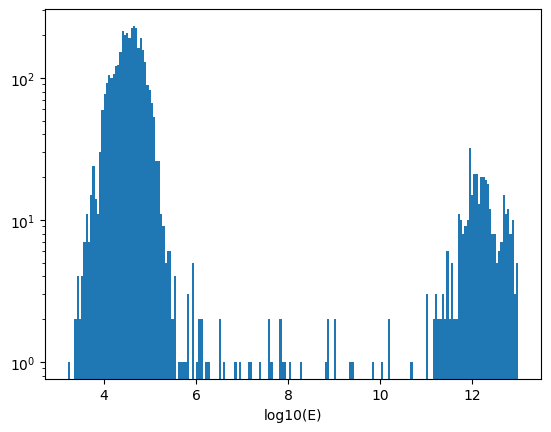

In [11]:
plt.hist(data.raw[:,0], bins=200);
plt.yscale('log')
plt.xlabel('log10(E)')

Text(0.5, 0, 'log10(E)')

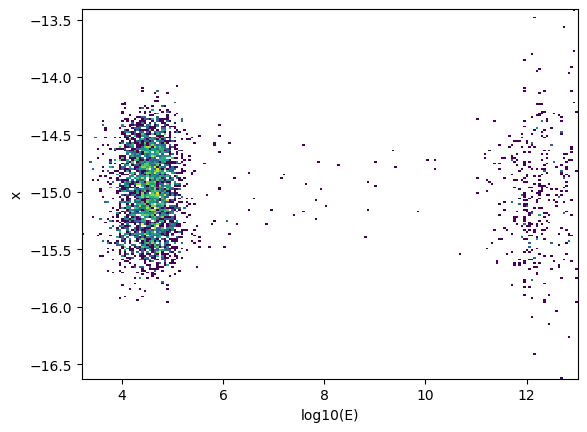

In [12]:
from matplotlib.colors import LogNorm
plt.hist2d(data.raw[:,0], data.raw[:,1], bins=200, norm=LogNorm());
plt.ylabel('x')
plt.xlabel('log10(E)')

In [13]:
def train_mcpl_flow(flow, dataloader, steps=500, lr=2e-3, report_every=100):
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    flow.train()
    losses = []
    
    for step in range(1, steps + 1):
        batch_loss = []
        for batch in dataloader:
            batch = batch.to(DEVICE)
            # Solution: maximum likelihood = minimize the negative log-likelihood.
            loss = -flow().log_prob(batch).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
            optimizer.step()
            batch_loss.append(loss.item())

        average_loss = torch.tensor(batch_loss).mean()
        losses.append(average_loss)
        
        if step == 1 or step % report_every == 0:
            print(f"step {step:4d} | NLL {average_loss:.3f}")

    return losses

In [18]:
model = zuko.flows.NICE(len(data[0]), transforms=4, hidden_features=(64, 64)).to(DEVICE)
dataloader = torch.utils.data.DataLoader(data, batch_size=256, shuffle=True)
losses = train_mcpl_flow(model, dataloader, steps=500, report_every=50)

step    1 | NLL 8.196
step   50 | NLL 3.613
step  100 | NLL 3.169
step  150 | NLL 2.636
step  200 | NLL 2.475
step  250 | NLL 2.360
step  300 | NLL 2.258
step  350 | NLL 2.428
step  400 | NLL 2.310
step  450 | NLL 2.261
step  500 | NLL 2.412


## Results exploration

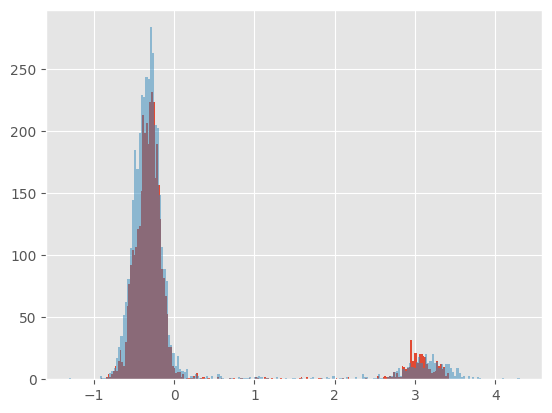

In [20]:
model.eval()
sample = model().sample((4000,))

plt.hist(data.particles[:,0].cpu(), bins=200);
plt.hist(sample[:,0].cpu(), bins=200, alpha=0.5);

(-1.0, 4.0)

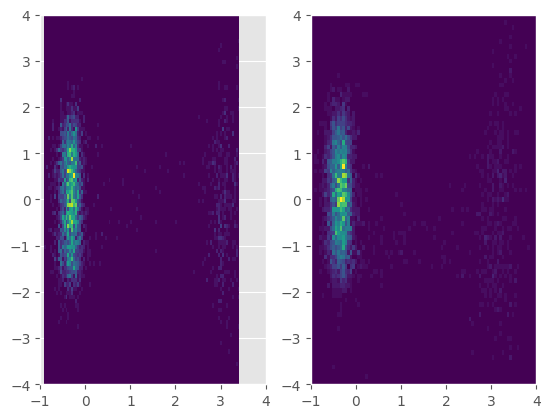

In [21]:
plt.subplot(121)
plt.hist2d(data.particles[:,0], data.particles[:,1], bins=100);
plt.ylim(-4,4)
plt.xlim(-1,4)
plt.subplot(122)
plt.hist2d(sample[:,0].cpu(), sample[:,1].cpu(), bins=100);
plt.ylim(-4,4)
plt.xlim(-1,4)

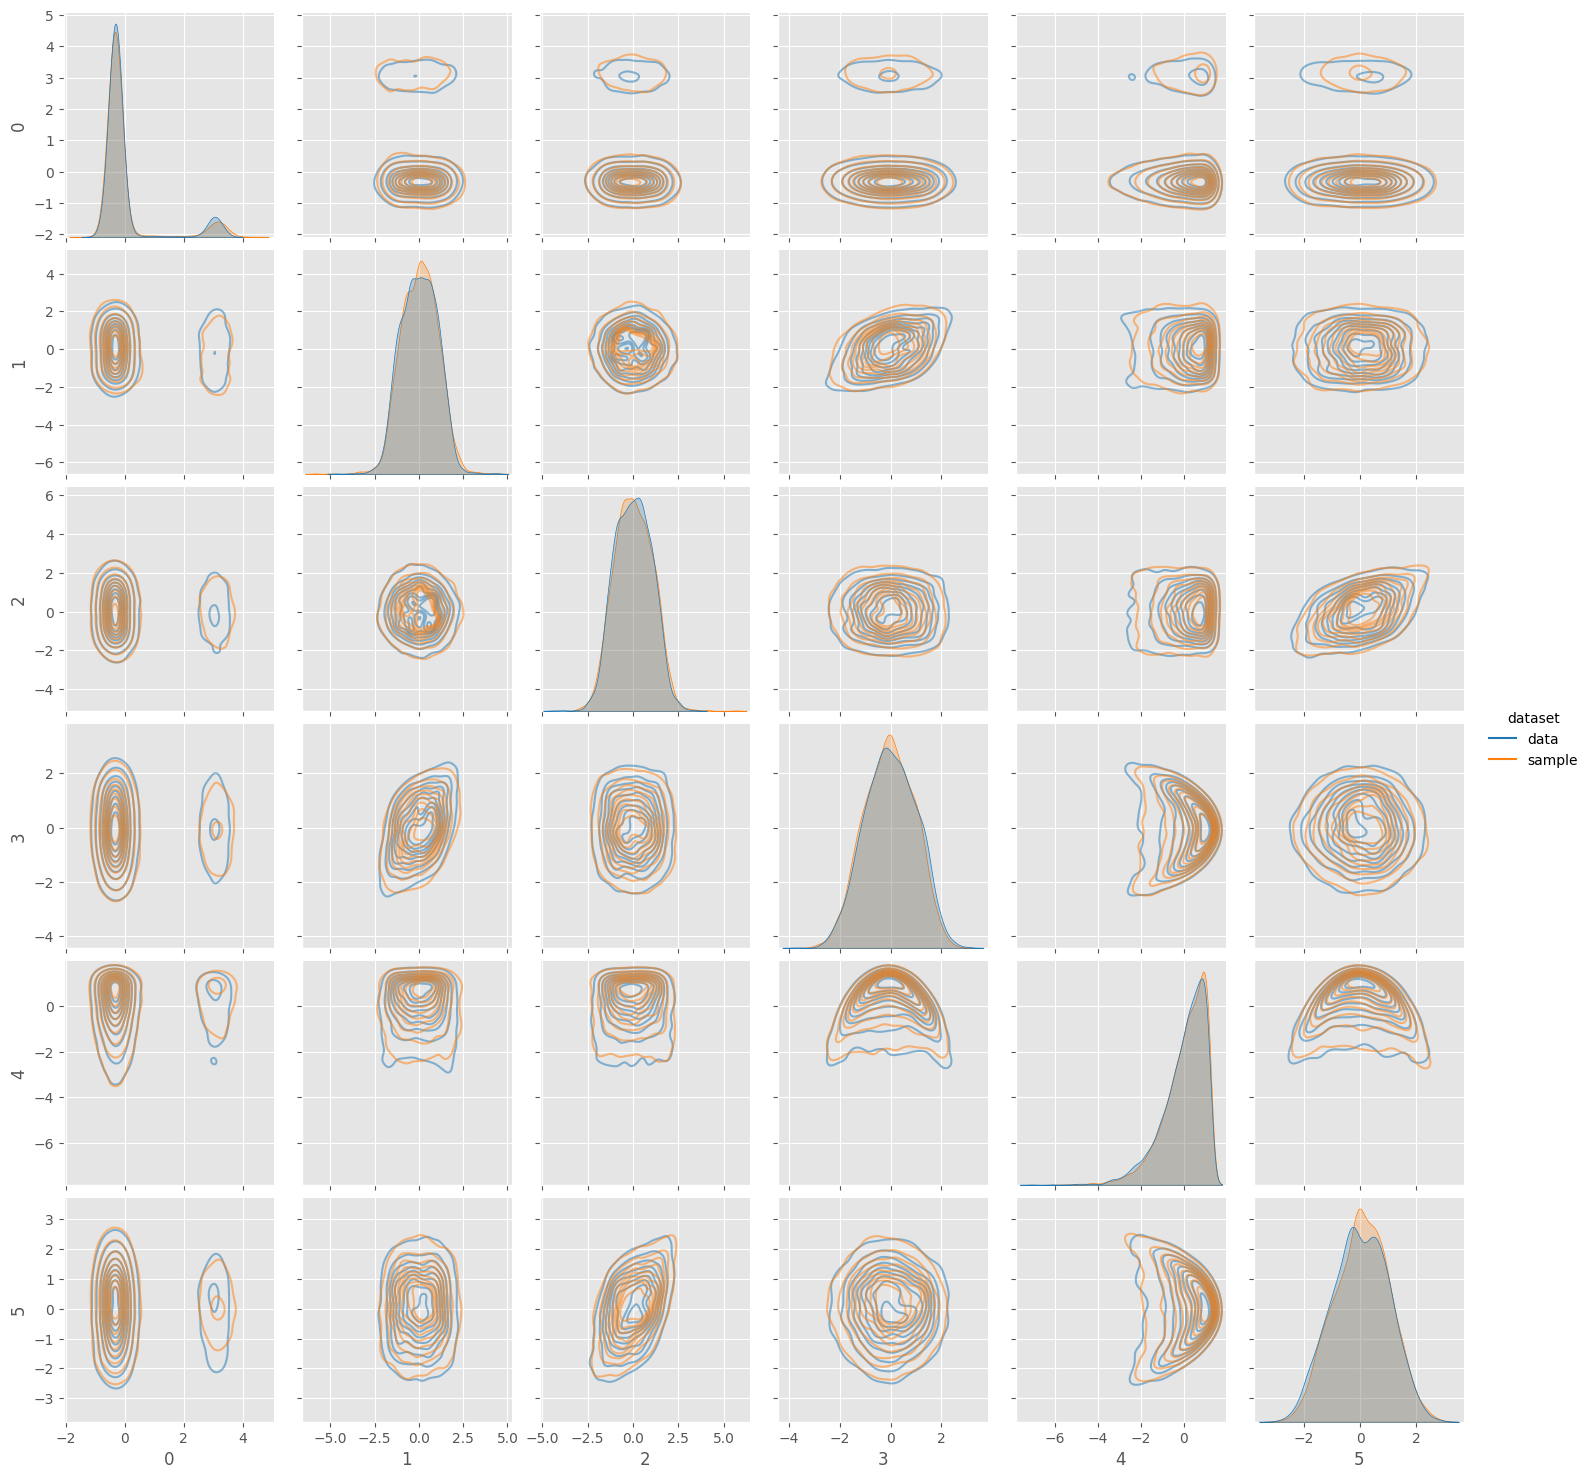

In [24]:
df1 = pd.DataFrame(data.particles)
df2 = pd.DataFrame(sample.cpu())

df1_plot = df1.assign(dataset="data")
df2_plot = df2.assign(dataset="sample")

combined = pd.concat([df1_plot, df2_plot], ignore_index=True)


sns.pairplot(
    combined,
    hue="dataset",
    palette={"data": "tab:blue", "sample": "tab:orange"},
    # corner=True,
    plot_kws={"alpha": 0.5, "s": 20},
    kind='kde'
)